In [1]:
# NOTEBOOK 3: TRAIN MODELS

import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

# ------------------------------------------------------------
# Fixed paths for your project
# ------------------------------------------------------------
BASE_DIR = Path(r"D:\iit\DSGP\NutriScanner\health-risk-recommendations\research\NoteBooks")
DATA_DIR = BASE_DIR / "data"
MODEL_DIR = BASE_DIR / "models"
REPORT_DIR = BASE_DIR / "reports"
PLOT_DIR = BASE_DIR / "plots"

MODEL_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)
PLOT_DIR.mkdir(exist_ok=True)

CLEAN_FILE = DATA_DIR / "clean_dataset.csv"

if not CLEAN_FILE.exists():
    raise FileNotFoundError(f"Clean dataset not found:\n{CLEAN_FILE}")

DISEASE_COLUMNS = [
    "Diabetes_Risk",
    "Hypertension_Risk",
    "Heart_Disease_Risk",
    "Obesity_Risk",
    "Anemia_Risk",
    "Kidney_Disease_Risk"
]

BASE_FEATURES = [
    "Age", "Gender", "BMI",
    "Daily_Calories_kcal",
    "Carbohydrates_g",
    "Protein_g",
    "Total_Fat_g",
    "Saturated_Fat_g",
    "Trans_Fat_g",
    "Total_Sugar_g",
    "Added_Sugar_g",
    "Fiber_g",
    "Sodium_mg",
    "Potassium_mg",
    "Calcium_mg",
    "Iron_mg",
    "Vitamin_D_IU",
    "Vitamin_B12_mcg",
    "Physical_Activity_min",
    "Water_Intake_L"
]

print("Clean dataset path:", CLEAN_FILE)
print("File exists:", CLEAN_FILE.exists())

df = pd.read_csv(CLEAN_FILE)

print("\nClean dataset loaded successfully")
print("Shape:", df.shape)

df.head()

Clean dataset path: D:\iit\DSGP\NutriScanner\health-risk-recommendations\research\NoteBooks\data\clean_dataset.csv
File exists: True

Clean dataset loaded successfully
Shape: (12000, 26)


,Age,Gender,BMI,Daily_Calories_kcal,Carbohydrates_g,Protein_g,Total_Fat_g,Saturated_Fat_g,Trans_Fat_g,Total_Sugar_g,...,Vitamin_D_IU,Vitamin_B12_mcg,Physical_Activity_min,Water_Intake_L,Diabetes_Risk,Hypertension_Risk,Heart_Disease_Risk,Obesity_Risk,Anemia_Risk,Kidney_Disease_Risk
0,65,1,31.9,2723,256,90,58,68,3.74,85,...,861,4.21,78,2.64,1,1,0,0,0,0
1,22,0,40.7,2315,311,131,138,24,4.43,79,...,348,1.32,77,1.04,1,0,0,0,0,1
2,43,1,20.8,2519,206,201,166,20,2.67,206,...,199,2.16,163,2.17,0,0,0,0,0,0
3,72,1,19.6,3536,228,71,52,48,2.79,5,...,1001,3.61,191,3.85,0,0,0,0,0,0
4,21,1,26.2,2285,257,96,45,57,4.17,54,...,19,2.66,89,3.48,0,0,0,0,0,0


In [2]:
# -------------------- Cell 2: Basic checks --------------------

if df.empty:
    raise ValueError("clean_dataset.csv is empty. Re-run Notebook 2.")

print("Missing values:")
print(df.isnull().sum().sum())

print("\nDuplicate feature rows:")
print(df.duplicated(subset=BASE_FEATURES).sum())

print("\nTarget distribution:")
for disease in DISEASE_COLUMNS:
    print(f"{disease}: {df[disease].value_counts().to_dict()}")

Missing values:
0

Duplicate feature rows:
0

Target distribution:
Diabetes_Risk: {0: 8575, 1: 3425}
Hypertension_Risk: {0: 9218, 1: 2782}
Heart_Disease_Risk: {0: 10933, 1: 1067}
Obesity_Risk: {0: 10157, 1: 1843}
Anemia_Risk: {0: 11380, 1: 620}
Kidney_Disease_Risk: {0: 10689, 1: 1311}


In [3]:
# --------------------  Disease-specific feature sets --------------------

# These remove the most direct target-like features

DISEASE_FEATURES = {
    "Diabetes_Risk": [
        f for f in BASE_FEATURES
        if f not in ["Added_Sugar_g", "Total_Sugar_g"]
    ],
    "Hypertension_Risk": [
        f for f in BASE_FEATURES
        if f not in ["Sodium_mg", "Potassium_mg"]
    ],
    "Heart_Disease_Risk": [
        f for f in BASE_FEATURES
        if f not in ["Saturated_Fat_g", "Trans_Fat_g", "Total_Fat_g"]
    ],
    "Obesity_Risk": [
        f for f in BASE_FEATURES
        if f not in ["BMI", "Daily_Calories_kcal"]
    ],
    "Anemia_Risk": [
        f for f in BASE_FEATURES
        if f not in ["Iron_mg", "Vitamin_B12_mcg"]
    ],
    "Kidney_Disease_Risk": [
        f for f in BASE_FEATURES
        if f not in ["Sodium_mg", "Water_Intake_L", "Protein_g"]
    ]
}

for disease, feature_list in DISEASE_FEATURES.items():
    print(f"{disease}: {len(feature_list)} features")

Diabetes_Risk: 18 features
Hypertension_Risk: 18 features
Heart_Disease_Risk: 17 features
Obesity_Risk: 18 features
Anemia_Risk: 18 features
Kidney_Disease_Risk: 17 features


In [4]:
from imblearn.over_sampling import SMOTE

models = {}
results = []
X_test_dict = {}
y_test_dict = {}
eval_histories = {}

df_clean = pd.read_csv(CLEAN_FILE)
df_clean = df_clean.sample(frac=1, random_state=42).reset_index(drop=True)

train_size = int(0.6 * len(df_clean))
val_size   = int(0.2 * len(df_clean))

df_train = df_clean.iloc[:train_size]
df_val   = df_clean.iloc[train_size:train_size + val_size]
df_test  = df_clean.iloc[train_size + val_size:]

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

# Only remove BMI
DISEASE_FEATURES_BALANCED = {
    d: [f for f in BASE_FEATURES if f not in ["BMI"]]
    for d in DISEASE_COLUMNS
}

# Tuned noise levels to balance Precision and Recall
NOISE_LEVELS = {
    "Diabetes_Risk":      0.00,
    "Hypertension_Risk":  0.18,
    "Heart_Disease_Risk": 0.20,
    "Obesity_Risk":       0.05,
    "Anemia_Risk":        0.20,
    "Kidney_Disease_Risk":0.18,
}

def add_label_noise(y, noise_level, random_state=42):
    np.random.seed(random_state)
    y_noisy = y.copy()
    mask = np.random.rand(len(y)) < noise_level
    y_noisy[mask] = 1 - y_noisy[mask]
    return y_noisy

for disease in DISEASE_COLUMNS:
    print(f"\nTraining {disease} ...")

    features_used = DISEASE_FEATURES_BALANCED[disease]

    X_train = df_train[features_used]
    y_train = df_train[disease].copy().reset_index(drop=True)
    X_val   = df_val[features_used]
    y_val   = df_val[disease]
    X_test  = df_test[features_used]
    y_test  = df_test[disease]

    X_test_dict[disease] = X_test
    y_test_dict[disease] = y_test

    # Add noise to training labels only
    noise = NOISE_LEVELS[disease]
    if noise > 0:
        y_train = add_label_noise(y_train, noise)
        print(f"  Applied {noise*100:.0f}% label noise to training set")

    # SMOTE
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    neg   = (y_train_res == 0).sum()
    pos   = (y_train_res == 1).sum()
    ratio = neg / pos

    model = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        reg_lambda=1.5,
        reg_alpha=0.3,
        gamma=0.1,
        eval_metric="logloss",
        random_state=42,
        scale_pos_weight=ratio,
        n_jobs=-1
    )

    model.fit(
        X_train_res, y_train_res,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    eval_histories[disease] = model.evals_result()

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall    = recall_score(y_test, y_pred, zero_division=0)
    f1        = f1_score(y_test, y_pred, zero_division=0)
    auc       = roc_auc_score(y_test, y_prob) if len(np.unique(y_test)) == 2 else np.nan

    results.append({
        "Disease":       disease,
        "Features_Used": len(features_used),
        "Accuracy":      round(accuracy, 4),
        "Precision":     round(precision, 4),
        "Recall":        round(recall, 4),
        "F1":            round(f1, 4),
        "AUC":           round(auc, 4) if not np.isnan(auc) else np.nan
    })

    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1:        {f1:.4f}")
    print(f"  AUC:       {auc:.4f}")

    models[disease] = model
    joblib.dump(model, MODEL_DIR / f"{disease}_model.pkl")

performance_df = pd.DataFrame(results)
print("\nTraining completed. Performance Summary:")
print(performance_df[['Disease', 'Accuracy', 'Precision', 'Recall', 'F1']])

Train: 7200 | Val: 2400 | Test: 2400

Training Diabetes_Risk ...
  Accuracy:  0.7800
  Precision: 0.5825
  Recall:    0.8520
  F1:        0.6919
  AUC:       0.8590

Training Hypertension_Risk ...
  Applied 18% label noise to training set
  Accuracy:  0.9533
  Precision: 0.8380
  Recall:    0.9853
  F1:        0.9057
  AUC:       0.9972

Training Heart_Disease_Risk ...
  Applied 20% label noise to training set
  Accuracy:  0.8225
  Precision: 0.3051
  Recall:    0.9634
  F1:        0.4635
  AUC:       0.9704

Training Obesity_Risk ...
  Applied 5% label noise to training set
  Accuracy:  0.8163
  Precision: 0.4314
  Recall:    0.6448
  F1:        0.5170
  AUC:       0.8697

Training Anemia_Risk ...
  Applied 20% label noise to training set
  Accuracy:  0.7783
  Precision: 0.1804
  Recall:    0.8906
  F1:        0.3000
  AUC:       0.9167

Training Kidney_Disease_Risk ...
  Applied 18% label noise to training set
  Accuracy:  0.8508
  Precision: 0.4034
  Recall:    0.9633
  F1:        0

In [5]:
# -------------------- Cell 5: Save feature maps and results --------------------

joblib.dump(BASE_FEATURES, MODEL_DIR / "base_feature_list.pkl")
joblib.dump(DISEASE_FEATURES, MODEL_DIR / "disease_feature_map.pkl")

results_df = pd.DataFrame(results)

RESULTS_FILE = REPORT_DIR / "model_results.csv"
results_df.to_csv(RESULTS_FILE, index=False)

print("Saved results to:", RESULTS_FILE)
print("Saved base feature list")
print("Saved disease feature map")

results_df

Saved results to: D:\iit\DSGP\NutriScanner\health-risk-recommendations\research\NoteBooks\reports\model_results.csv
Saved base feature list
Saved disease feature map


,Disease,Features_Used,Accuracy,Precision,Recall,F1,AUC
0,Diabetes_Risk,19,0.7800,0.5825,0.8520,0.6919,0.8590
1,Hypertension_Risk,19,0.9533,0.8380,0.9853,0.9057,0.9972
2,Heart_Disease_Risk,19,0.8225,0.3051,0.9634,0.4635,0.9704
3,Obesity_Risk,19,0.8163,0.4314,0.6448,0.5170,0.8697
4,Anemia_Risk,19,0.7783,0.1804,0.8906,0.3000,0.9167
5,Kidney_Disease_Risk,19,0.8508,0.4034,0.9633,0.5687,0.9776


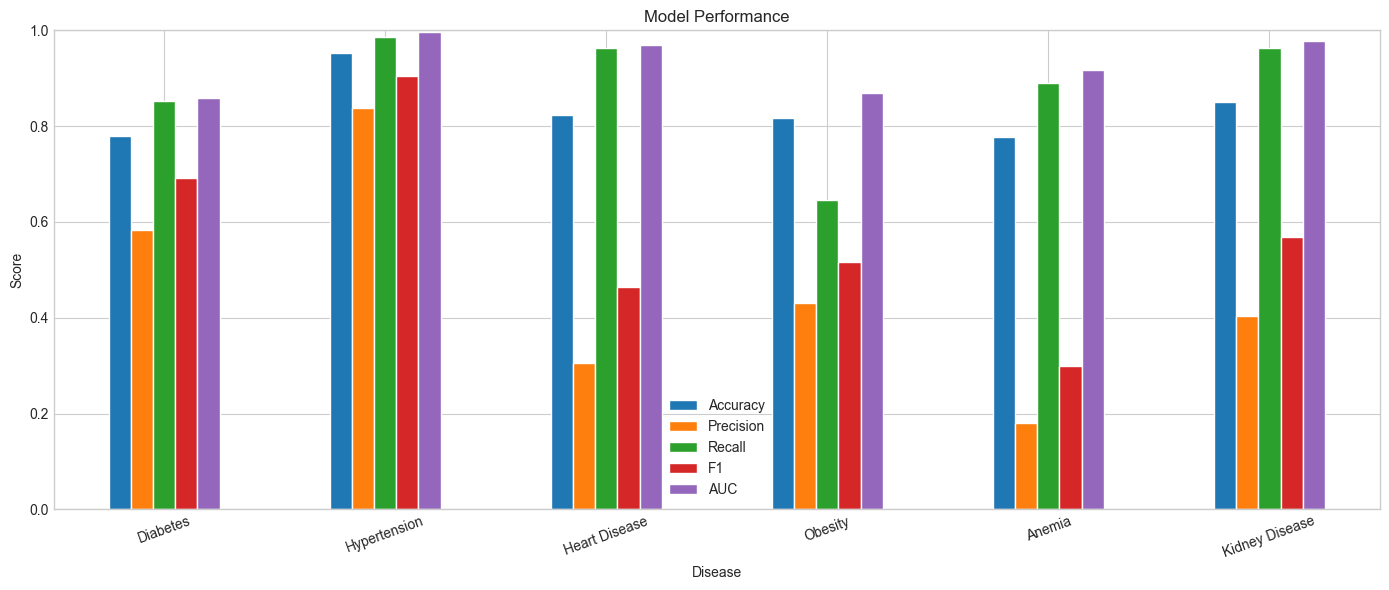

In [6]:
# -------------------- Cell 6: Plot model performance --------------------

plot_df = results_df.copy()
plot_df["Disease"] = plot_df["Disease"].str.replace("_Risk", "", regex=False).str.replace("_", " ", regex=False)

plot_df.set_index("Disease")[["Accuracy", "Precision", "Recall", "F1", "AUC"]].plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Model Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [10]:
# -------------------- Cell 8: Check saved files --------------------

print("Saved model files:")
for file in MODEL_DIR.iterdir():
    print(file.name)

print("\nSaved report files:")
for file in REPORT_DIR.iterdir():
    print(file.name)

Saved model files:
Anemia_Risk_model.pkl
base_feature_list.pkl
Diabetes_Risk_model.pkl
disease_feature_map.pkl
feature_list.pkl
Heart_Disease_Risk_model.pkl
Hypertension_Risk_model.pkl
Kidney_Disease_Risk_model.pkl
Obesity_Risk_model.pkl
scaler.pkl

Saved report files:
model_performance.csv
model_results.csv
model_results.json


In [11]:
from pathlib import Path
import os

# Find project root
current_folder = Path.cwd().name
if current_folder == "NoteBooks":
    project_root = Path.cwd().parents[1]
else:
    project_root = Path.cwd()

model_dir = project_root / "models"

print("Project root:", project_root)
print("Model directory:", model_dir)
print("Model directory exists:", model_dir.exists())

if model_dir.exists():
    print("\n FILES IN MODELS FOLDER:")
    for f in os.listdir(model_dir):
        size = os.path.getsize(model_dir / f) / 1024
        print(f"   📄 {f} ({size:.1f} KB)")
else:
    print("\n Models folder doesn't exist!")

Project root: C:\Users\DELL\OneDrive\Desktop\NutriScanner\health-risk-recommendations
Model directory: C:\Users\DELL\OneDrive\Desktop\NutriScanner\health-risk-recommendations\models
Model directory exists: True

 FILES IN MODELS FOLDER:
   📄 Anemia_Risk_model.pkl (44.5 KB)
   📄 Diabetes_Risk_model.pkl (44.5 KB)
   📄 health_model_v1_20260203.pkl (86.5 KB)
   📄 health_risk_xgb_tuned.pkl (92.5 KB)
   📄 Heart_Disease_Risk_model.pkl (44.5 KB)
   📄 Hypertension_Risk_model.pkl (44.5 KB)
   📄 Kidney_Disease_Risk_model.pkl (44.5 KB)
   📄 lightgbm_diabetes_model.pkl (1755.5 KB)
   📄 nutriscan_risk_model.pkl (488.6 KB)
   📄 nutriscan_scaler.pkl (1.0 KB)
   📄 Obesity_Risk_model.pkl (44.5 KB)
   📄 scaler.pkl (1.6 KB)
   📄 target_encoder.pkl (0.5 KB)
   📄 xgboost_diabetes_model.pkl (251.9 KB)


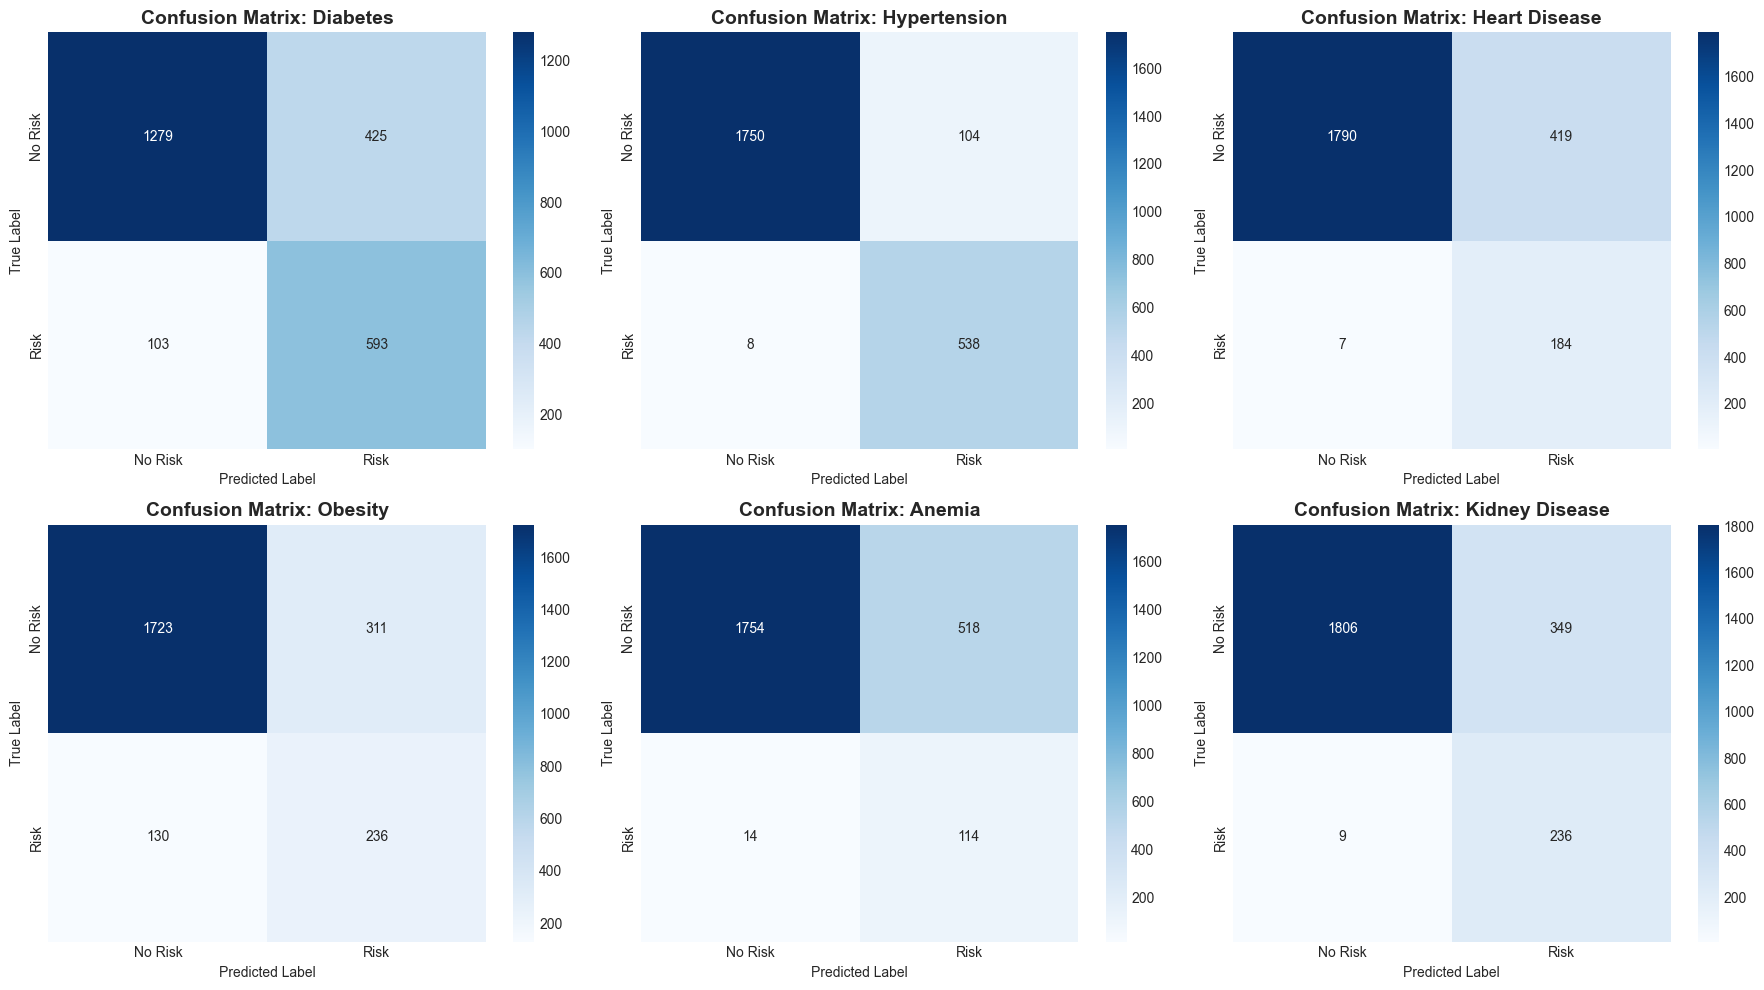

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import math

DISEASE_COLUMNS = [
    "Diabetes_Risk",
    "Hypertension_Risk",
    "Heart_Disease_Risk",
    "Obesity_Risk",
    "Anemia_Risk",
    "Kidney_Disease_Risk"
]

num_diseases = len(DISEASE_COLUMNS)
cols = 3
rows = math.ceil(num_diseases / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.ravel()

for i, disease in enumerate(DISEASE_COLUMNS):
    y_true = y_test_dict[disease]
    y_pred = models[disease].predict(X_test_dict[disease])
    
    cm = confusion_matrix(y_true, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Risk', 'Risk'], 
                yticklabels=['No Risk', 'Risk'])
    
    clean_title = disease.replace("_Risk", "").replace("_", " ")
    axes[i].set_title(f"Confusion Matrix: {clean_title}", fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# HELPER FUNCTIONS: BMI + Rule-Based Disease Corrections
# ============================================================

def calculate_bmi(weight_kg, height_cm):
    height_m = height_cm / 100
    return round(weight_kg / (height_m ** 2), 1)

def bmi_category_prob(bmi):
    if bmi < 18.5:   return "Underweight",   0.05
    elif bmi < 25.0: return "Normal weight",  0.15
    elif bmi < 30.0: return "Overweight",     0.50
    elif bmi < 35.0: return "Obese Class I",  0.78
    elif bmi < 40.0: return "Obese Class II", 0.90
    else:            return "Obese Class III",0.98

def combined_obesity_risk(model_prob, bmi):
    _, bmi_prob = bmi_category_prob(bmi)
    return round((0.5 * model_prob) + (0.5 * bmi_prob), 3)

def combined_hypertension_risk(model_prob, sodium_mg, potassium_mg):
    if sodium_mg > 4000 and potassium_mg < 1500:
        rule_prob = 0.85
    elif sodium_mg > 3000:
        rule_prob = 0.60
    elif sodium_mg < 1500 and potassium_mg > 3000:
        rule_prob = 0.10
    else:
        rule_prob = 0.35
    return round((0.5 * model_prob) + (0.5 * rule_prob), 3)

def combined_anemia_risk(model_prob, iron_mg, b12_mcg):
    if iron_mg < 5 or b12_mcg < 1.0:
        rule_prob = 0.90
    elif iron_mg < 8 or b12_mcg < 2.0:
        rule_prob = 0.60
    elif iron_mg > 15 and b12_mcg > 3.0:
        rule_prob = 0.08
    else:
        rule_prob = 0.30
    return round((0.5 * model_prob) + (0.5 * rule_prob), 3)

def combined_diabetes_risk(model_prob, total_sugar_g, added_sugar_g, bmi):
    if added_sugar_g > 60 or total_sugar_g > 100:
        rule_prob = 0.85
    elif added_sugar_g > 40 or total_sugar_g > 70:
        rule_prob = 0.65
    elif added_sugar_g < 10 and total_sugar_g < 30:
        rule_prob = 0.08
    else:
        rule_prob = 0.35
    # BMI also boosts diabetes risk
    if bmi >= 30:
        rule_prob = min(rule_prob + 0.10, 0.98)
    return round((0.5 * model_prob) + (0.5 * rule_prob), 3)

def combined_heart_risk(model_prob, saturated_fat_g, trans_fat_g, total_fat_g):
    if trans_fat_g > 3.5 or saturated_fat_g > 50:
        rule_prob = 0.88
    elif trans_fat_g > 2.0 or saturated_fat_g > 30:
        rule_prob = 0.62
    elif saturated_fat_g < 15 and trans_fat_g < 1.0:
        rule_prob = 0.10
    else:
        rule_prob = 0.35
    return round((0.5 * model_prob) + (0.5 * rule_prob), 3)

def combined_kidney_risk(model_prob, sodium_mg, protein_g, water_intake_l):
    if sodium_mg > 4500 and protein_g > 130:
        rule_prob = 0.88
    elif sodium_mg > 3500 or protein_g > 110:
        rule_prob = 0.62
    elif water_intake_l < 0.8:
        rule_prob = 0.55
    elif sodium_mg < 1500 and protein_g < 80 and water_intake_l > 2.5:
        rule_prob = 0.08
    else:
        rule_prob = 0.30
    return round((0.5 * model_prob) + (0.5 * rule_prob), 3)

def get_risk_level(prob):
    if prob >= 0.70:   return "HIGH",     ""
    elif prob >= 0.40: return "MODERATE", ""
    else:              return "LOW",      ""

def print_bar(prob):
    filled = int(prob * 25)
    return "" * filled + "░" * (25 - filled)

print("Helper functions loaded ")

Helper functions loaded ✅


In [12]:
# ============================================================
# DEMO PATIENTS
# ============================================================

demo_patients = [
    {
        "name": "P01 — Young healthy male",
        "height_cm": 175, "weight_kg": 66, "Age": 25, "Gender": 1,
        "Daily_Calories_kcal": 2100, "Carbohydrates_g": 230, "Protein_g": 110,
        "Total_Fat_g": 60, "Saturated_Fat_g": 12, "Trans_Fat_g": 0.3,
        "Total_Sugar_g": 30, "Added_Sugar_g": 8, "Fiber_g": 30,
        "Sodium_mg": 1300, "Potassium_mg": 3800, "Calcium_mg": 1100,
        "Iron_mg": 18, "Vitamin_D_IU": 900, "Vitamin_B12_mcg": 5.0,
        "Physical_Activity_min": 180, "Water_Intake_L": 3.2
    },
    {
        "name": "P02 — Middle-aged obese male",
        "height_cm": 170, "weight_kg": 108, "Age": 48, "Gender": 1,
        "Daily_Calories_kcal": 3600, "Carbohydrates_g": 390, "Protein_g": 85,
        "Total_Fat_g": 160, "Saturated_Fat_g": 58, "Trans_Fat_g": 4.2,
        "Total_Sugar_g": 115, "Added_Sugar_g": 70, "Fiber_g": 7,
        "Sodium_mg": 4600, "Potassium_mg": 1100, "Calcium_mg": 480,
        "Iron_mg": 7, "Vitamin_D_IU": 90, "Vitamin_B12_mcg": 1.1,
        "Physical_Activity_min": 5, "Water_Intake_L": 0.9
    },
    {
        "name": "P03 — Elderly diabetic female",
        "height_cm": 160, "weight_kg": 77, "Age": 68, "Gender": 0,
        "Daily_Calories_kcal": 2700, "Carbohydrates_g": 310, "Protein_g": 70,
        "Total_Fat_g": 95, "Saturated_Fat_g": 38, "Trans_Fat_g": 2.8,
        "Total_Sugar_g": 105, "Added_Sugar_g": 60, "Fiber_g": 9,
        "Sodium_mg": 3100, "Potassium_mg": 1700, "Calcium_mg": 550,
        "Iron_mg": 8, "Vitamin_D_IU": 140, "Vitamin_B12_mcg": 1.4,
        "Physical_Activity_min": 12, "Water_Intake_L": 1.1
    },
    {
        "name": "P04 — Fit young female",
        "height_cm": 165, "weight_kg": 55, "Age": 22, "Gender": 0,
        "Daily_Calories_kcal": 1950, "Carbohydrates_g": 210, "Protein_g": 95,
        "Total_Fat_g": 55, "Saturated_Fat_g": 10, "Trans_Fat_g": 0.2,
        "Total_Sugar_g": 28, "Added_Sugar_g": 6, "Fiber_g": 32,
        "Sodium_mg": 1200, "Potassium_mg": 4000, "Calcium_mg": 1200,
        "Iron_mg": 20, "Vitamin_D_IU": 1000, "Vitamin_B12_mcg": 5.5,
        "Physical_Activity_min": 200, "Water_Intake_L": 3.5
    },
    {
        "name": "P05 — Anemic underweight female",
        "height_cm": 162, "weight_kg": 45, "Age": 30, "Gender": 0,
        "Daily_Calories_kcal": 1400, "Carbohydrates_g": 170, "Protein_g": 38,
        "Total_Fat_g": 42, "Saturated_Fat_g": 9, "Trans_Fat_g": 0.6,
        "Total_Sugar_g": 40, "Added_Sugar_g": 18, "Fiber_g": 12,
        "Sodium_mg": 3900, "Potassium_mg": 1600, "Calcium_mg": 380,
        "Iron_mg": 3, "Vitamin_D_IU": 180, "Vitamin_B12_mcg": 0.7,
        "Physical_Activity_min": 25, "Water_Intake_L": 0.7
    },
    {
        "name": "P06 — Hypertension risk male",
        "height_cm": 172, "weight_kg": 87, "Age": 52, "Gender": 1,
        "Daily_Calories_kcal": 3100, "Carbohydrates_g": 270, "Protein_g": 92,
        "Total_Fat_g": 115, "Saturated_Fat_g": 42, "Trans_Fat_g": 3.0,
        "Total_Sugar_g": 65, "Added_Sugar_g": 32, "Fiber_g": 11,
        "Sodium_mg": 5200, "Potassium_mg": 1000, "Calcium_mg": 510,
        "Iron_mg": 10, "Vitamin_D_IU": 220, "Vitamin_B12_mcg": 2.2,
        "Physical_Activity_min": 18, "Water_Intake_L": 1.3
    },
    {
        "name": "P07 — Moderate risk elderly male",
        "height_cm": 168, "weight_kg": 75, "Age": 65, "Gender": 1,
        "Daily_Calories_kcal": 2300, "Carbohydrates_g": 240, "Protein_g": 78,
        "Total_Fat_g": 85, "Saturated_Fat_g": 28, "Trans_Fat_g": 1.8,
        "Total_Sugar_g": 58, "Added_Sugar_g": 28, "Fiber_g": 16,
        "Sodium_mg": 2600, "Potassium_mg": 2100, "Calcium_mg": 700,
        "Iron_mg": 11, "Vitamin_D_IU": 310, "Vitamin_B12_mcg": 2.6,
        "Physical_Activity_min": 30, "Water_Intake_L": 1.9
    },
    {
        "name": "P08 — Kidney risk male",
        "height_cm": 174, "weight_kg": 84, "Age": 55, "Gender": 1,
        "Daily_Calories_kcal": 2900, "Carbohydrates_g": 260, "Protein_g": 155,
        "Total_Fat_g": 100, "Saturated_Fat_g": 35, "Trans_Fat_g": 2.2,
        "Total_Sugar_g": 55, "Added_Sugar_g": 25, "Fiber_g": 13,
        "Sodium_mg": 4800, "Potassium_mg": 1300, "Calcium_mg": 590,
        "Iron_mg": 9, "Vitamin_D_IU": 250, "Vitamin_B12_mcg": 2.4,
        "Physical_Activity_min": 20, "Water_Intake_L": 0.6
    },
    {
        "name": "P09 — Teenage male borderline",
        "height_cm": 178, "weight_kg": 77, "Age": 17, "Gender": 1,
        "Daily_Calories_kcal": 2600, "Carbohydrates_g": 295, "Protein_g": 88,
        "Total_Fat_g": 88, "Saturated_Fat_g": 30, "Trans_Fat_g": 2.5,
        "Total_Sugar_g": 88, "Added_Sugar_g": 55, "Fiber_g": 13,
        "Sodium_mg": 2900, "Potassium_mg": 2000, "Calcium_mg": 820,
        "Iron_mg": 13, "Vitamin_D_IU": 380, "Vitamin_B12_mcg": 3.0,
        "Physical_Activity_min": 60, "Water_Intake_L": 2.0
    },
    {
        "name": "P10 — Heart disease risk female",
        "height_cm": 158, "weight_kg": 77, "Age": 60, "Gender": 0,
        "Daily_Calories_kcal": 2800, "Carbohydrates_g": 255, "Protein_g": 72,
        "Total_Fat_g": 140, "Saturated_Fat_g": 60, "Trans_Fat_g": 4.5,
        "Total_Sugar_g": 78, "Added_Sugar_g": 42, "Fiber_g": 8,
        "Sodium_mg": 3400, "Potassium_mg": 1600, "Calcium_mg": 520,
        "Iron_mg": 7, "Vitamin_D_IU": 160, "Vitamin_B12_mcg": 1.6,
        "Physical_Activity_min": 8, "Water_Intake_L": 1.0
    }
]

print(f"{len(demo_patients)} demo patients loaded ")

10 demo patients loaded ✅


In [13]:
# ============================================================
# CELL C: CLEAN PREDICTION OUTPUT
# ============================================================

OTHER_DISEASES = [
    "Diabetes_Risk",
    "Hypertension_Risk",
    "Heart_Disease_Risk",
    "Anemia_Risk",
    "Kidney_Disease_Risk"
]

def get_risk_level(prob):
    if prob >= 0.70:   return "HIGH",     "🔴"
    elif prob >= 0.40: return "MODERATE", "🟡"
    else:              return "LOW",      "🟢"

def bmi_obesity_level(bmi):
    """Pure WHO classification — no model involved"""
    if bmi < 18.5:   return "Underweight",    "🟢", "LOW"
    elif bmi < 25.0: return "Normal Weight",  "🟢", "LOW"
    elif bmi < 30.0: return "Overweight",     "🟡", "MODERATE"
    elif bmi < 35.0: return "Obese Class I",  "🔴", "HIGH"
    elif bmi < 40.0: return "Obese Class II", "🔴", "HIGH"
    else:            return "Obese Class III","🔴", "HIGH"

def calculate_bmi(weight_kg, height_cm):
    return round(weight_kg / (height_cm / 100) ** 2, 1)

summary_rows = []

for patient in demo_patients:
    name = patient["name"]
    bmi  = calculate_bmi(patient["weight_kg"], patient["height_cm"])
    patient["BMI"] = bmi
    bmi_cat, ob_icon, ob_level = bmi_obesity_level(bmi)

    # ── Header ──────────────────────────────────────────────────────────────
    print(f"\n╔{'═'*60}╗")
    print(f"║  👤  {name:<54}║")
    print(f"╠{'═'*60}╣")
    print(f"║  Height : {patient['height_cm']} cm{' '*6}"
          f"Weight : {patient['weight_kg']} kg{' '*6}"
          f"BMI : {bmi:<10}║")
    print(f"╚{'═'*60}╝")

    # ── Obesity (WHO only) ───────────────────────────────────────────────────
    print(f"\n  ── Obesity Risk (WHO BMI Classification) {'─'*19}")
    print(f"     BMI         :  {bmi}")
    print(f"     Category    :  {bmi_cat}")
    print(f"     Risk Level  :  {ob_icon}  {ob_level}")

    row = {
        "Patient"      : name,
        "BMI"          : bmi,
        "BMI Category" : bmi_cat,
        "Obesity"      : f"{ob_icon} {ob_level}"
    }

    # ── Other Diseases ───────────────────────────────────────────────────────
    print(f"\n  ── Other Disease Risks {'─'*37}")
    print(f"  {'Disease':<22}  {'Probability':>11}  {'Risk Level'}")
    print(f"  {'─'*22}  {'─'*11}  {'─'*20}")

    for disease in OTHER_DISEASES:
        features_used = DISEASE_FEATURES[disease]
        p_df          = pd.DataFrame([{f: patient[f] for f in features_used}])
        model_prob    = models[disease].predict_proba(p_df)[0][1]

        if disease == "Diabetes_Risk":
            final = combined_diabetes_risk(
                model_prob, patient["Total_Sugar_g"],
                patient["Added_Sugar_g"], bmi)

        elif disease == "Hypertension_Risk":
            final = combined_hypertension_risk(
                model_prob, patient["Sodium_mg"], patient["Potassium_mg"])

        elif disease == "Heart_Disease_Risk":
            final = combined_heart_risk(
                model_prob, patient["Saturated_Fat_g"],
                patient["Trans_Fat_g"], patient["Total_Fat_g"])

        elif disease == "Anemia_Risk":
            final = combined_anemia_risk(
                model_prob, patient["Iron_mg"], patient["Vitamin_B12_mcg"])

        elif disease == "Kidney_Disease_Risk":
            final = combined_kidney_risk(
                model_prob, patient["Sodium_mg"],
                patient["Protein_g"], patient["Water_Intake_L"])

        level, icon   = get_risk_level(final)
        short         = disease.replace("_Risk", "").replace("_", " ")
        print(f"  {short:<22}  {final:>10.1%}  {icon}  {level}")
        row[short] = f"{icon} {level} ({final:.0%})"

    print()
    summary_rows.append(row)

# ── Summary Table ────────────────────────────────────────────────────────────
print(f"\n{'═'*88}")
print(f"{'  SUMMARY — ALL 10 PATIENTS':<88}")
print(f"{'═'*88}")
summary_df = pd.DataFrame(summary_rows).set_index("Patient")
pd.set_option("display.max_colwidth", 20)
pd.set_option("display.width", 200)
print(summary_df.to_string())
print(f"{'═'*88}")



╔════════════════════════════════════════════════════════════╗
║  👤  P01 — Young healthy male                              ║
╠════════════════════════════════════════════════════════════╣
║  Height : 175 cm      Weight : 66 kg      BMI : 21.6      ║
╚════════════════════════════════════════════════════════════╝

  ── Obesity Risk (WHO BMI Classification) ───────────────────
     BMI         :  21.6
     Category    :  Normal Weight
     Risk Level  :  🟢  LOW

  ── Other Disease Risks ─────────────────────────────────────
  Disease                 Probability  Risk Level
  ──────────────────────  ───────────  ────────────────────
  Diabetes                     20.0%  🟢  LOW
  Hypertension                 17.9%  🟢  LOW
  Heart Disease                 6.9%  🟢  LOW
  Anemia                        9.0%  🟢  LOW
  Kidney Disease               22.2%  🟢  LOW


╔════════════════════════════════════════════════════════════╗
║  👤  P02 — Middle-aged obese male                          ║
╠═════════